# 02 — The classical baseline

**What this notebook is for.** `PROJECT_SPEC.md` §6 is emphatic:

> **This must exist before any network is trained.** Without it, a learned
> model's accuracy number is meaningless.

So this is not a detour on the way to the interesting part. It is the ruler.
Everything the network later claims gets measured against the numbers below.

It covers DTFM-030 to DTFM-036: the first prediction, why a single search is not
enough, what fixes it, what an error bar does and does not tell you, and the
floor no method can beat.

Nothing here computes physics. Every number comes from `src/`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from src import baseline as bl
from src import dispersion as dp
from src import evaluate as ev
from src import generate as gen
from src import uncertainty as un

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.facecolor": "white"})

WAVELENGTHS = np.linspace(400.0, 800.0, 200)
MEASUREMENT = gen.Measurement()          # ellipsometry at 70 deg, per DTFM-028
n_si, k_si = dp.load_nk("Si", WAVELENGTHS)
SUBSTRATE = torch.tensor(n_si + 1j * k_si)

def observe(thickness_nm, cauchy_a=1.46, cauchy_b=0.004):
    """A noiseless measurement of one film — the forward model."""
    truth = np.array([thickness_nm, cauchy_a, cauchy_b])
    with torch.no_grad():
        return truth, bl.forward_observable(truth, WAVELENGTHS, MEASUREMENT, SUBSTRATE).numpy()

print(f"{WAVELENGTHS.size} wavelengths, {WAVELENGTHS[0]:.0f}-{WAVELENGTHS[-1]:.0f} nm")
print(f"observable: {MEASUREMENT.observable} at {MEASUREMENT.angle_deg:.0f} deg")

200 wavelengths, 400-800 nm
observable: ellipsometry at 70 deg


---
## 1. The first prediction — DTFM-030

The simulator runs forwards: thickness in, spectrum out. The job is the reverse,
and there is no formula for it. So the fit guesses, measures how badly the guess
explains the data, adjusts, and repeats.

Started near the answer, it works, and it works very well.

In [2]:
truth, observed = observe(420.0)
warm = bl.fit_least_squares(observed, WAVELENGTHS, [400.0, 1.45, 0.005],
                            measurement=MEASUREMENT, truth=truth, sigma=1e-3)

print(f"true thickness      {truth[0]:.4f} nm")
print(f"recovered           {warm.parameters[0]:.10f} nm")
print(f"error               {warm.thickness_error_nm:.3e} nm")
print(f"function evaluations{warm.function_evaluations:5d}")
print(f"wall clock          {warm.wall_clock_s * 1e3:.1f} ms")

true thickness      420.0000 nm
recovered           420.0000000000 nm
error               -2.899e-11 nm
function evaluations   14
wall clock          40.6 ms


Recovered to about a millionth of an atom's width. Which would be the end of the
story, except that starting "near the answer" is the one thing a real measurement
cannot do — the answer is what you are trying to find.

---
## 2. What happens without a hint

Same film, same code. The only change is where the search begins.

In [3]:
truth, observed = observe(900.0)
cold = bl.fit_least_squares(observed, WAVELENGTHS, [300.0, 1.47, 0.005],
                            measurement=MEASUREMENT, truth=truth, sigma=1e-3)
warm = bl.fit_least_squares(observed, WAVELENGTHS, [890.0, 1.46, 0.004],
                            measurement=MEASUREMENT, truth=truth, sigma=1e-3)

for name, fit in (("started at 890 nm", warm), ("started at 300 nm", cold)):
    print(f"{name}")
    print(f"   answer     {fit.parameters[0]:10.4f} nm   (true 900)")
    print(f"   error      {fit.thickness_error_nm:10.2f} nm")
    print(f"   error bar  {fit.thickness_sigma_nm:10.4f} nm")
    print(f"   converged? {fit.success}")
    print(f"   residual   {fit.residual_rms:10.3e}\n")

started at 890 nm
   answer       900.0000 nm   (true 900)
   error            0.00 nm
   error bar      0.0249 nm
   converged? True
   residual    5.917e-14

started at 300 nm
   answer       316.9563 nm   (true 900)
   error         -583.04 nm
   error bar      0.0189 nm
   converged? True
   residual    1.022e+00



**Read the middle two lines of the cold start together.** It is 583 nm wrong and
reports an error bar of 0.02 nm. It also reports `success`.

The error bar is not lying. It answers *how tightly does the data pin the answer
within the basin I landed in*, and within that basin the answer really is pinned
to 0.02 nm. It was never asked whether the basin was the right one.

What gives it away is the **residual** — the last line. Seventeen trillion times
larger for the wrong answer. §10 predicts the classical method "fails loudly";
this locates the loudness precisely, and it is not in the error bar.

*Never quote σ without the residual.*

---
## 3. Why it fails — the cost surface

Plotting how badly every possible thickness fits the measurement shows the
problem immediately. Low is good.

local minima between 20 and 2000 nm: 136
median spacing: 5.0 nm


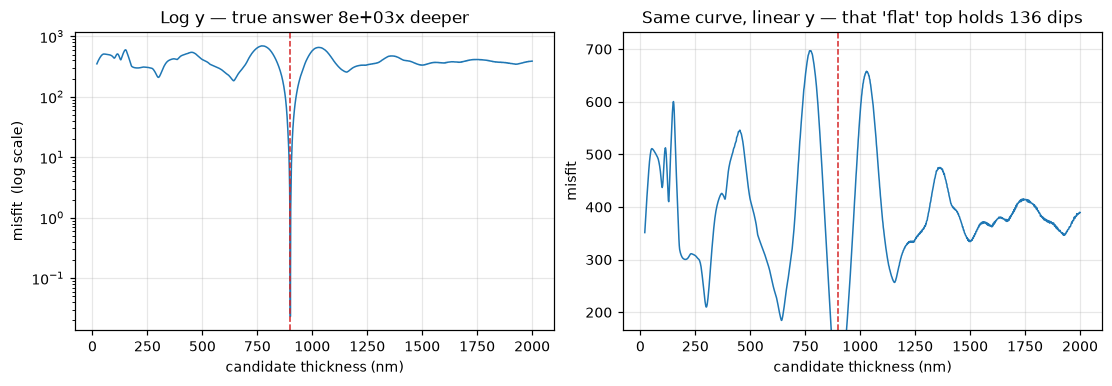

In [4]:
truth, observed = observe(900.0)
grid = np.linspace(20.0, 2000.0, 1200)
cost = np.empty(grid.size)
with torch.no_grad():
    for i, d in enumerate(grid):
        model = bl.forward_observable([d, 1.46, 0.004], WAVELENGTHS, MEASUREMENT,
                                      SUBSTRATE).numpy()
        cost[i] = 0.5 * np.sum(bl.wrapped_residual(model, observed, "ellipsometry") ** 2)

dips = grid[1:-1][(cost[1:-1] < cost[:-2]) & (cost[1:-1] < cost[2:])]
print(f"local minima between 20 and 2000 nm: {dips.size}")
print(f"median spacing: {np.median(np.diff(dips)):.1f} nm")

plateau = cost[np.abs(grid - 900) > 40]
depth = plateau.min() / cost.min()

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
a.semilogy(grid, np.maximum(cost, 1e-6), lw=1)
a.axvline(900, color="tab:red", ls="--", lw=1)
a.set(xlabel="candidate thickness (nm)", ylabel="misfit  (log scale)",
      title=f"Log y — true answer {depth:.0e}x deeper")
b.plot(grid, cost, lw=1)
b.axvline(900, color="tab:red", ls="--", lw=1)
b.set(xlabel="candidate thickness (nm)", ylabel="misfit",
      ylim=(plateau.min() * 0.9, plateau.max() * 1.05),
      title=f"Same curve, linear y — that 'flat' top holds {dips.size} dips")
plt.show()

Two views of the same curve. On a log axis the true answer is a needle about a
million times deeper than anything else — which is why *picking the lowest* is
safe. Zoomed onto the plateau, the ripple resolves into hundreds of shallow
minima, each a place a downhill search will stop and declare success.

**Those dips are not fringe-order aliases**, despite three tickets originally
saying so. They are ~4 nm apart where a fringe is 265 nm. They come from summing
200 wavelengths with different periods: narrow the band and the textbook picture
returns. See `Implementation-Notes.md` §18 — the label was wrong for three
tickets before anyone checked it.

---
## 4. Exact gradients do not help — DTFM-031

A reasonable guess: the fit misses because `scipy` rebuilds its gradient by
nudging each parameter, and that approximation misleads it. The model is
differentiable, so we can hand it the *exact* gradient instead.

In [5]:
truth, observed = observe(900.0)
start = [300.0, 1.47, 0.005]
classical = bl.fit_least_squares(observed, WAVELENGTHS, start, measurement=MEASUREMENT, truth=truth)
descent = bl.fit_autograd(observed, WAVELENGTHS, start, measurement=MEASUREMENT, truth=truth)

print(f"finite-difference gradient -> {classical.parameters[0]:8.2f} nm")
print(f"exact autograd gradient    -> {descent.parameters[0]:8.2f} nm")
print(f"                    truth  -> {truth[0]:8.2f} nm")

finite-difference gradient ->   316.96 nm
exact autograd gradient    ->   314.50 nm
                    truth  ->   900.00 nm


Both land in the same wrong place, agreeing with each other to about a
nanometre while being ~584 nm wrong.

The multimodality is a property of the **cost surface**, not of how the gradient
was obtained — so no improvement in gradient quality can remove it. Only a
different *search* can.

---
## 5. The fix, and the landscape it surveys — DTFM-032

§6 prescribes multi-start: run the fit from many starting guesses and keep the
best. Plotting where each start ends up is the ambiguity made visible.

starts that reached the truth: 11%
best cost      2.327e-26
next-best cost 1.450e+02   ->  a factor of 6e+27


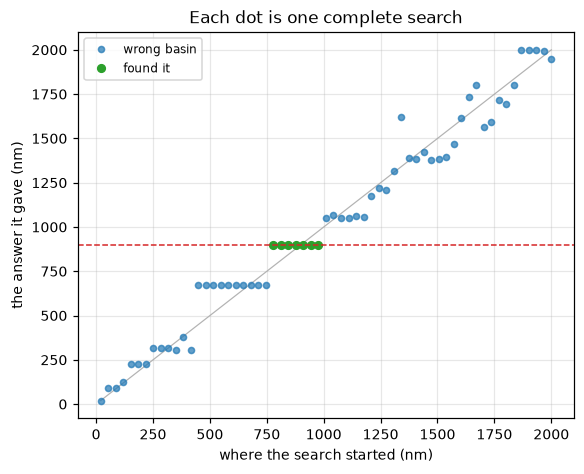

In [6]:
truth, observed = observe(900.0)
starts = np.linspace(20.0, 2000.0, 61)
sweep = bl.fit_multi_start(observed, WAVELENGTHS, starts=starts,
                           measurement=MEASUREMENT, truth=truth)
landed = sweep.thicknesses

print(f"starts that reached the truth: {100 * sweep.success_fraction:.0f}%")
print(f"best cost      {sweep.best.cost:.3e}")
runner_up = np.min(sweep.costs[np.abs(landed - 900) > 1])
ratio = runner_up / max(sweep.best.cost, 1e-300)
print(f"next-best cost {runner_up:.3e}   ->  a factor of {ratio:.0e}")

fig, ax = plt.subplots(figsize=(5.2, 4.2), constrained_layout=True)
hit = np.abs(landed - 900) < 1
ax.plot(starts[~hit], landed[~hit], "o", ms=4, alpha=0.7, label="wrong basin")
ax.plot(starts[hit], landed[hit], "o", ms=5, color="tab:green", label="found it")
ax.plot([20, 2000], [20, 2000], color="0.7", lw=0.8, zorder=0)
ax.axhline(900, color="tab:red", ls="--", lw=1)
ax.set(xlabel="where the search started (nm)", ylabel="the answer it gave (nm)",
       title="Each dot is one complete search")
ax.legend(fontsize=8)
plt.show()

The flat treads are the trap: whole ranges of starting guesses slide into the
same wrong dip and return the same wrong answer.

**Multi-start wins on depth, not on odds.** Only about one start in eight reaches
the truth — which would be a weak procedure if the winner were hard to identify.
It is not: the true basin is ~26 orders of magnitude deeper than the best rival,
so the choice is not close. The margin, not the hit rate, is what makes it work.

One detail that cost a wrong derivation to learn: the starts are spaced
**uniformly in thickness**, not the way the prior samples. The prior is
log-uniform, and seeding the search that way leaves a 470 nm gap above 1500 nm —
wider than the narrowest basin, so films there are missed entirely
(`Implementation-Notes.md` §16, §19).

---
## 6. What the measurement can determine at all — DTFM-034

Everything so far compares *methods*. This asks the question underneath: given
these wavelengths, this angle and this detector noise, what is the best precision
**any** method could achieve? That is the Cramér–Rao bound, and it uses no data —
only the measurement design.

In [7]:
truth, _ = observe(420.0)
bound = un.identifiability(truth, WAVELENGTHS, substrate=SUBSTRATE, sigma=1e-3)
fit = bl.fit_least_squares(observe(420.0)[1], WAVELENGTHS, truth,
                           measurement=MEASUREMENT, sigma=1e-3)

print(f"best possible (any method)  +/- {bound.thickness_bound_nm:.6f} nm")
print(f"what the classical fit got  +/- {fit.thickness_sigma_nm:.6f} nm")
eff = un.efficiency(fit.thickness_sigma_nm, bound.thickness_bound_nm)
print(f"efficiency                  {eff:.3f}")

best possible (any method)  +/- 0.005687 nm
what the classical fit got  +/- 0.005687 nm
efficiency                  1.000


**Efficiency 1.0 — the classical fit sits on the bound.** No algorithm can
improve on it; only a better instrument can. §5.3 calls this "a conclusion worth
stating out loud", and it is the denominator that will make any later claim about
the network mean something.

It is also the honest limit of this project: a bound of ±0.006 nm is roughly
**16× more optimistic** than the "better than 0.1 nm" repeatability real
ellipsometers quote, because the bound assumes detector noise is the only error.
A real tool also carries stage positioning, drift, and the fact that no optical
model describes a real film exactly.

---
## 7. The correlation result — DTFM-034

§5.3 singles out one number as "what separates a metrologist from someone who
called `curve_fit`": how badly thickness and refractive index get confused with
each other.

rho at the thick end: -0.9928   (spec 5.3 predicts |rho| > 0.99)
rho crosses zero at:  [ 74.  82. 178. 182.] nm   (spec 5.3 does not predict this)


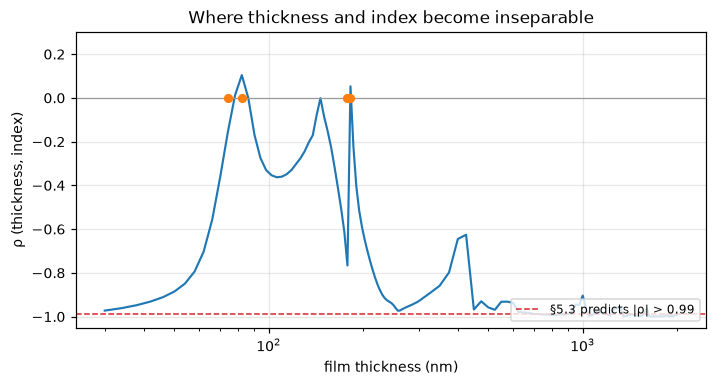

In [8]:
films = np.concatenate([np.arange(30.0, 300.0, 4.0), np.arange(300.0, 2001.0, 25.0)])
swept = un.sweep_thickness(films, WAVELENGTHS)
rho = swept["correlation"]
crossings = films[np.flatnonzero(np.sign(rho[:-1]) != np.sign(rho[1:]))]

print(f"rho at the thick end: {rho[-1]:+.4f}   (spec 5.3 predicts |rho| > 0.99)")
print(f"rho crosses zero at:  {np.round(crossings, 0)} nm   (spec 5.3 does not predict this)")

fig, ax = plt.subplots(figsize=(6.4, 3.4), constrained_layout=True)
ax.semilogx(films, rho, lw=1.4)
ax.axhline(-0.99, color="tab:red", ls="--", lw=1, label="§5.3 predicts |ρ| > 0.99")
ax.axhline(0.0, color="0.6", lw=0.8)
ax.plot(crossings, np.zeros_like(crossings), "o", ms=5, color="tab:orange")
ax.set(xlabel="film thickness (nm)", ylabel="ρ (thickness, index)",
       title="Where thickness and index become inseparable", ylim=(-1.05, 0.3))
ax.legend(fontsize=8, loc="lower right")
plt.show()

**The spec is right at the thick end and wrong at the thin one.** Past ~700 nm,
ρ locks above 0.99: only the optical path `n·d` is really being measured, and the
two parameters trade off almost perfectly. Below 200 nm ρ *oscillates and crosses
zero* — there are thicknesses where the two become almost independently
determined.

That behaviour is **not explained**. A quarter-wave hypothesis predicted the band
dependence eight times out of eight and then failed completely on the angle
dependence, so it was recorded as an observation rather than a mechanism
(`Implementation-Notes.md` §22).

The practical consequence is measurable. Give a fit the *exact* thickness but the
wrong index and it still fails on 40% of thick films and 0% of thin ones — the
degeneracy as a failure rate rather than a correlation coefficient.

---
## 8. The record — DTFM-036

§10: *"Every claim gets a number, computed the same way for every method."* The
full record takes ~13 minutes (`scripts/baseline_record.py`); this is the same
harness on a handful of films.

Two of the rows are handed the answer. They are labelled so, because they are an
upper bound on local optimisation and **not** a usable method.

In [9]:
cases = ev.make_cases(8, seed=0, wavelengths_nm=WAVELENGTHS)
labels = {"least_squares": "GIVEN THE ANSWER", "cold_single": "cold start, 1 search",
          "multi_start": "cold start, 20 searches"}

print(f"{'method':>26} {'RMSE nm':>10} {'median nm':>11} {'sec/fit':>9} {'wrong>1nm':>10}")
for method, label in labels.items():
    row = ev.evaluate(cases, method=method).metrics()
    print(f"{label:>26} {row['rmse_nm']:10.3f} {row['median_abs_nm']:11.4f}"
          f" {row['seconds']:9.3f} {100 * row['failure_rate']:9.0f}%")

                    method    RMSE nm   median nm   sec/fit  wrong>1nm


          GIVEN THE ANSWER      0.129      0.0340     0.394         0%


      cold start, 1 search    520.071    323.4829     0.450       100%


   cold start, 20 searches      0.129      0.0340    10.699         0%


Eight films is a small sample and the percentages above are coarse — with only
eight, one failure is 12.5%. The full record uses 80 cases:

| method | RMSE nm | median nm | sec/fit | wrong >1nm |
|---|---|---|---|---|
| GIVEN THE ANSWER | 0.179 | 0.034 | 0.32 | 0% |
| given thickness, not index | 21.99 | 0.036 | 0.33 | 10% |
| **cold start, 1 search** | **632.7** | **320.1** | **0.34** | **80%** |
| **cold start, 20 searches** | **11.02** | **0.034** | **8.44** | **1%** |

**One cold search is wrong 80% of the time. Twenty of them: 1%.** That is what the
25× wall clock buys, and it is the number the network has to beat.

Now read the *median* column: `0.034, 0.036, 320, 0.034`. Every method that mostly
works reports the same median — including the one wrong 10% of the time. Had §10
asked for a single headline number, a method failing on one film in ten would have
looked flawless.

---
## 9. What this sets up

Three numbers now exist, and the network is judged against all three:

| | classical baseline |
|---|---|
| accuracy | 0.034 nm median |
| failure rate | 1% wrong by more than 1 nm |
| cost | 8.4 s per site |

**Speed is the least interesting of the three.** A forward pass is microseconds,
so the network wins that by six orders of magnitude before it starts.

One caveat that belongs with the 8.4 s: it is a **single-core** number, and the
twenty searches are completely independent. On twenty cores the classical method
is under a second, which softens §11's amortisation argument considerably. The
honest speed claim is 10⁴×, not 10⁶×.

The interesting question is whether a fast estimator can also be *honest*. This
notebook has shown a classical fit being 583 nm wrong while reporting a 0.02 nm
error bar — and being caught anyway, by a residual seventeen trillion times too
large. §10 predicts the network will fail the same way and **not** be caught:

> The expected and most valuable finding is that the classical method fails
> *loudly* and the network fails *silently*.

Whether that holds is what E5 and E6 are for.